# ⚡ Proyecto Bootcamp IA ⚡

## 🎲 Análisis exploratorio de los Datos (EDA) 🎲

In [ ]:
# 💎 Importación de las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# 💎 Lectura del excel (.xlsx)
df = pd.read_excel("data.xlsx") 
df_copy = df.copy()
display(df.head())

,Institución Educativa Distrital -IED,Deporte,Sexo,Edad (años cumplidos),Peso (kg),Talla (cm),Talla Sentado (cm),Envergadura (cm),Balón Medicinal,Salto Largo,10 x 5 (s),30 m lanzados (s),Wells,Leger,Velocidad Máxima (Course Navette - km h^-1)
0,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,40.0,148.0,77.0,149.0,305.0,113.0,19.5,7.0,30.0,3.0,9.5
1,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,53.0,158.0,82.0,158.0,400.0,142.0,17.8,6.2,18.0,NaN,NaN
2,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,46.0,156.0,80.0,153.0,310.0,145.0,19.3,6.5,29.0,3.0,9.5
3,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,53.0,147.0,77.0,146.0,335.0,129.0,19.7,7.1,22.0,3.0,9.5
4,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,51.0,158.0,83.0,157.0,360.0,148.0,17.2,6.2,22.0,3.0,9.5


### ⚜️ Tratamiento de datos nulos

In [57]:
# 💎 Imprimir las columnas 
print(df.columns)

# 💎 Imprimir la suma de los nulos por columna 
print("\n Nulos por columnas de los datos: \n", df_copy.isnull().sum())

Index(['Institución Educativa Distrital -IED', 'Deporte', 'Sexo',
       'Edad (años cumplidos)', 'Peso (kg)', 'Talla (cm)',
       'Talla Sentado (cm)', 'Envergadura (cm)', 'Balón Medicinal',
       'Salto Largo', '10 x 5 (s)', '30 m lanzados (s)', 'Wells', 'Leger',
       'Velocidad Máxima (Course Navette - km h^-1)'],
      dtype='object')

 Nulos por columnas de los datos: 
 Institución Educativa Distrital -IED            0
Deporte                                         0
Sexo                                            0
Edad (años cumplidos)                           0
Peso (kg)                                       0
Talla (cm)                                      0
Talla Sentado (cm)                              0
Envergadura (cm)                                0
Balón Medicinal                                 0
Salto Largo                                     0
10 x 5 (s)                                      0
30 m lanzados (s)                               0
Wells             

In [71]:
# 💎 Rellenar los valores de Leger con la media.
if "Leger" in df:
    df["Leger"] = df["Leger"].fillna(df["Leger"].mean())

# Imprimir la suma de los nulos por columna 
# print("\n Nulos por columnas de los datos: \n", df.isnull().sum())

# 💎 No hay columnas con exceso de nulos que puedan ser borradas...

# 💎 Cambiar el nombre de la columna Velocidad Máxima (Course Navette - km h^-1) y Edad (años cumplidos)
#     por Velocida Maxima y Edad respectivamente.
df = df.rename(columns={"Velocidad Máxima (Course Navette - km h^-1)" : "Velocidad Maxima"})
df = df.rename(columns={"Edad (años cumplidos)": "Edad"})

# 💎 Rellenar los valores de Velocidad Máxima con la media.
if "Velocidad Maxima" in df:
    df["Velocidad Maxima"] = df["Velocidad Maxima"].fillna(df["Velocidad Maxima"].mean())

# Imprimir la suma de los nulos por columna.
print("\n Nulos por columnas de los datos: \n", df.isnull().sum())


 Nulos por columnas de los datos: 
 Institución Educativa Distrital -IED    0
Deporte                                 0
Sexo                                    0
Edad                                    0
Peso (kg)                               0
Talla (cm)                              0
Talla Sentado (cm)                      0
Envergadura (cm)                        0
Balón Medicinal                         0
Salto Largo                             0
10 x 5 (s)                              0
30 m lanzados (s)                       0
Wells                                   0
Leger                                   0
Velocidad Maxima                        0
IMC                                     0
dtype: int64


### ⚜️ Histograma de las Tallas

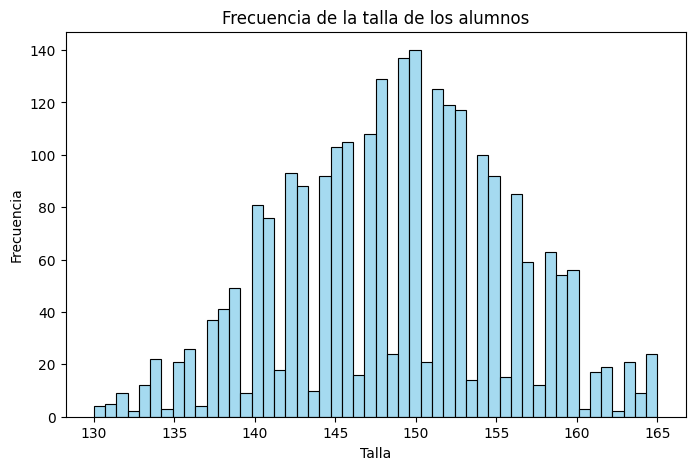

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(df["Talla (cm)"], bins=50, color="skyblue")
plt.title("Frecuencia de la talla de los alumnos")
plt.xlabel("Talla")
plt.ylabel("Frecuencia")
plt.show()

### ⚜️ Diagrama de caja (Boxplot) de la Talla por el Sexo

C:\Users\equipo\AppData\Local\Temp\ipykernel_12244\3643336844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Sexo", y="Talla (cm)", data=df, palette="Set2")


Text(0, 0.5, 'Talla (cm)')

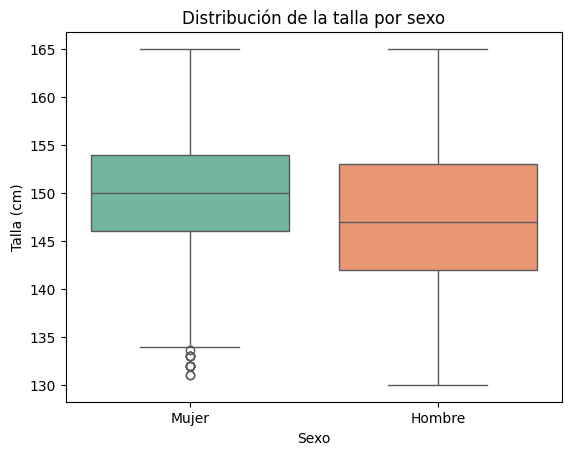

In [73]:
plt.figure()
sns.boxplot(x="Sexo", y="Talla (cm)", data=df, palette="Set2")
plt.title("Distribución de la talla por sexo")
plt.xlabel("Sexo")
plt.ylabel("Talla (cm)")

### ⚜️ Diagrama de correlación

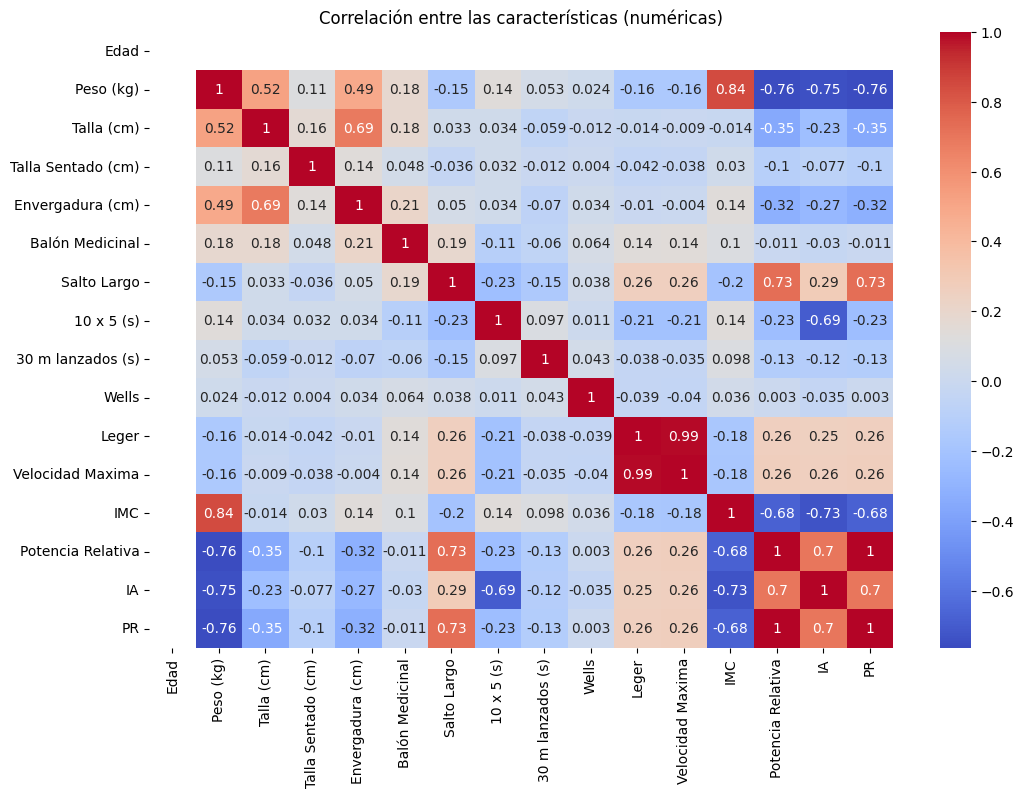

In [98]:
df_numerico = df.select_dtypes(include="number")
correlacion_matriz = df_numerico.corr().round(3)
plt.figure(figsize=(12, 8)) # Ajusta el tamaño de la figura
sns.heatmap(
    correlacion_matriz, 
    annot=True, 
    cmap="coolwarm",
    annot_kws = {"size": 10} # Ajusta el tamaño de la fuente
)
plt.title("Correlación entre las características (numéricas)")
plt.show()

### ⚜️ Diagrama de sectores de mujeres y hombres

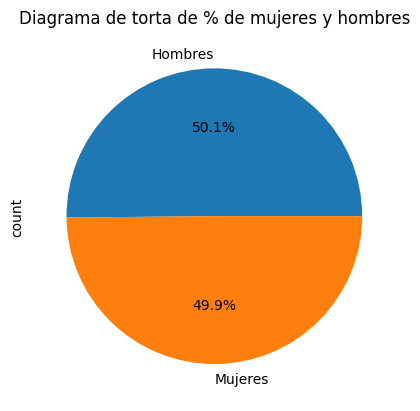


Numero de hombres y mujeres: 
 Sexo
Hombre    1249
Mujer     1242
Name: count, dtype: int64


In [62]:
plt.figure()
df.Sexo.value_counts().plot(kind="pie", labels=["Hombres", "Mujeres"],
                            title="Diagrama de torta de % de mujeres y hombres", autopct="%1.1f%%")
plt.show()

print("\nNumero de hombres y mujeres: \n", df["Sexo"].value_counts())

### ⚜️ Diagrama de barras con el numero de personas por deporte

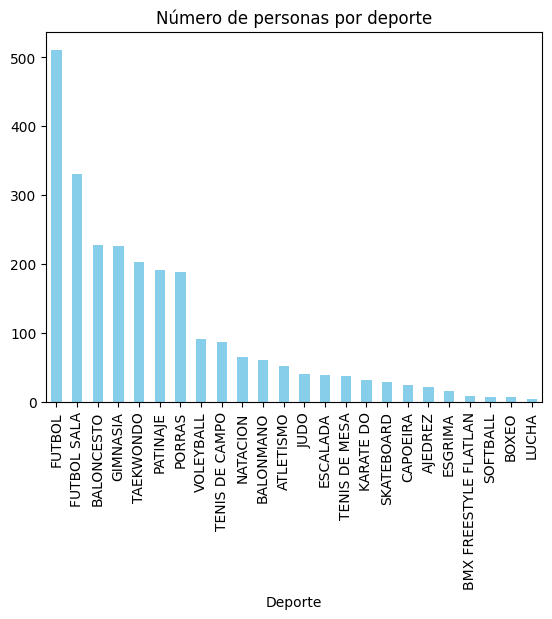

In [68]:
df.Deporte.value_counts().plot(kind="bar", title="Número de personas por deporte", color="skyblue")
plt.show()

In [ ]:
print("Dimensiones: ", df.shape)
print("\nNúmero de elementos: ", df.size)
print("\nNombre de las filas: ", df.index)
print("\nTipos de datos: \n", df.dtypes)
display("Primeras 10 filas: ",  df.head(10))
display("Ultimas 10 filas: ",  df.tail(10))

Dimensiones:  (2491, 15)

Número de elementos:  37365

Nombre de las filas:  RangeIndex(start=0, stop=2491, step=1)

Tipos de datos: 
 Institución Educativa Distrital -IED     object
Deporte                                  object
Sexo                                     object
Edad (años cumplidos)                     int64
Peso (kg)                               float64
Talla (cm)                              float64
Talla Sentado (cm)                      float64
Envergadura (cm)                        float64
Balón Medicinal                         float64
Salto Largo                             float64
10 x 5 (s)                              float64
30 m lanzados (s)                       float64
Wells                                   float64
Leger                                   float64
Velocidad Maxima                        float64
dtype: object


'Primeras 10 filas: '

,Institución Educativa Distrital -IED,Deporte,Sexo,Edad (años cumplidos),Peso (kg),Talla (cm),Talla Sentado (cm),Envergadura (cm),Balón Medicinal,Salto Largo,10 x 5 (s),30 m lanzados (s),Wells,Leger,Velocidad Maxima
0,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,40.0,148.0,77.0,149.0,305.0,113.0,19.5,7.00,30.0,3.000000,9.500000
1,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,53.0,158.0,82.0,158.0,400.0,142.0,17.8,6.20,18.0,4.023222,10.013716
2,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,46.0,156.0,80.0,153.0,310.0,145.0,19.3,6.50,29.0,3.000000,9.500000
3,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,53.0,147.0,77.0,146.0,335.0,129.0,19.7,7.10,22.0,3.000000,9.500000
4,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,51.0,158.0,83.0,157.0,360.0,148.0,17.2,6.20,22.0,3.000000,9.500000
5,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,51.0,155.0,80.0,153.0,315.0,143.0,19.1,6.40,29.0,3.000000,9.500000
6,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,52.0,151.0,79.0,152.0,327.0,122.0,18.5,6.30,21.0,3.000000,9.500000
7,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,49.0,152.0,77.0,151.0,285.0,129.0,17.2,6.90,24.0,3.000000,9.500000
8,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,47.0,157.0,80.0,155.0,305.0,131.0,18.9,6.90,21.0,3.000000,9.500000
9,COL EDUARDO SANTOS (IED),AJEDREZ,Mujer,12,47.3,151.1,76.6,157.0,239.0,118.3,23.9,6.24,23.5,3.000000,9.500000


'Ultimas 10 filas: '

,Institución Educativa Distrital -IED,Deporte,Sexo,Edad (años cumplidos),Peso (kg),Talla (cm),Talla Sentado (cm),Envergadura (cm),Balón Medicinal,Salto Largo,10 x 5 (s),30 m lanzados (s),Wells,Leger,Velocidad Maxima
2481,COL PROSPERO PINZON (IED),VOLEYBALL,Mujer,12,51.0,156.0,72.0,160.0,280.0,105.0,27.54,6.06,14.0,4.0,10.0
2482,COL RAFAEL BERNAL JIMENEZ (IED),VOLEYBALL,Mujer,12,48.0,150.0,80.0,155.0,238.0,107.0,25.22,6.15,13.0,3.0,9.5
2483,COL RAFAEL BERNAL JIMENEZ (IED),VOLEYBALL,Mujer,12,58.0,155.0,78.0,160.0,270.0,163.0,20.39,5.70,15.0,3.0,9.5
2484,COL SIMON RODRIGUEZ (IED),VOLEYBALL,Mujer,12,43.0,150.0,78.0,149.0,380.0,156.0,21.10,5.25,12.0,4.0,10.0
2485,COL SIMON RODRIGUEZ (IED),VOLEYBALL,Mujer,12,50.0,155.0,80.0,157.0,460.0,105.0,20.15,6.40,30.0,3.0,9.5
2486,COL SIMON RODRIGUEZ (IED),VOLEYBALL,Mujer,12,45.0,152.0,77.0,154.0,380.0,154.0,20.05,5.77,32.0,5.0,10.5
2487,COL SIMON RODRIGUEZ (IED),VOLEYBALL,Mujer,12,47.0,152.0,76.0,157.0,210.0,140.0,19.76,6.40,10.0,3.0,9.5
2488,COL SIMON RODRIGUEZ (IED),VOLEYBALL,Mujer,12,48.0,147.0,77.0,150.0,405.0,130.0,24.35,5.21,27.0,3.0,9.5
2489,COL SIMON RODRIGUEZ (IED),VOLEYBALL,Mujer,12,35.0,146.0,73.0,145.0,330.0,139.0,19.40,6.50,18.0,1.0,8.5
2490,COL SIMON RODRIGUEZ (IED),VOLEYBALL,Mujer,12,35.0,147.0,75.0,156.0,246.0,127.0,26.86,5.15,29.0,3.0,9.5


### ⚜️ Descripción estadística

In [ ]:
display(df.describe())

,Edad (años cumplidos),Peso (kg),Talla (cm),Talla Sentado (cm),Envergadura (cm),Balón Medicinal,Salto Largo,10 x 5 (s),30 m lanzados (s),Wells,Leger,Velocidad Maxima
count,2491.0,2491.000000,2491.000000,2491.000000,2491.000000,2491.000000,2491.000000,2491.000000,2491.000000,2491.000000,2491.000000,2491.000000
mean,12.0,41.960169,148.723244,78.124785,149.474067,322.791088,139.160859,21.692198,5.929916,20.992701,4.023222,10.013716
std,0.0,7.271014,6.965763,10.795773,8.079095,71.655069,21.679729,3.313163,1.442906,6.880460,1.706653,0.844673
min,12.0,28.500000,130.000000,60.000000,127.000000,150.000000,89.000000,15.800000,4.290000,4.000000,0.000000,8.500000
25%,12.0,36.400000,144.000000,73.000000,144.000000,274.500000,123.000000,19.400000,5.180000,16.000000,3.000000,9.500000
50%,12.0,41.000000,149.000000,76.000000,150.000000,320.000000,139.000000,21.100000,5.650000,21.000000,4.000000,10.000000
75%,12.0,46.700000,154.000000,80.000000,155.000000,370.000000,152.000000,23.120000,6.270000,26.000000,5.000000,10.500000
max,12.0,63.400000,165.000000,126.400000,169.000000,533.000000,210.000000,39.300000,19.200000,37.000000,12.000000,14.000000


## 🎲 Preguntas específicas

### ⚜️ Deporte en el que más participan los estudiantes

In [ ]:
print("El deporte que más practican los estudiantes es:", df["Deporte"].mode()[0])

El deporte que más practican los estudiantes es: FUTBOL


### ⚜️ Instituciones educativas con más y menos estudiantes 

In [52]:
df_cant = df["Institución Educativa Distrital -IED"].value_counts()
display(df_cant)

print(f"La IE con mas estudiantes inscritos es: {df_cant.index[0]} con {df_cant.iloc[0]} estudiantes")
print(f"La IE con mas estudiantes inscritos es: {df_cant.index[-1]} con {df_cant.iloc[-1]}")

Institución Educativa Distrital -IED
COMUNIDAD1                                   271
COL TOMAS CARRASQUILLA (IED)                 139
COL COLOMBIA VIVA (IED)                      126
COL FEDERICO GARCIA LORCA (IED)              103
COL MANUELA BELTRAN (IED)                     99
                                            ... 
COL LIC NAL AGUSTIN NIETO CABALLERO (IED)      4
COL NUEVA ESPERANZA (IED)                      3
COL INST TEC DISTRITAL JULIO FLOREZ (IED)      3
COL MANUEL ELKIN PATARROYO (IED)               2
COL RAFAEL BERNAL JIMENEZ (IED)                2
Name: count, Length: 62, dtype: int64

La IE con mas estudiantes inscritos es: COMUNIDAD1 con 271 estudiantes
La IE con mas estudiantes inscritos es: COL RAFAEL BERNAL JIMENEZ (IED) con 2


### ⚜️ Agregar columnas de: 
```
° IMC (Indice de Masa Corporal) -> Peso/((Talla/100)^2)
° PR (Potencia relativa) -> (Salto Largo/Peso)
° IA (Indice de Agilidad) -> Altura/(10x5 (s) X Peso (kg))
```

In [96]:
df["IMC"] = df["Peso (kg)"]/((df["Talla (cm)"]/100)**2)

df["PR"] = df["Salto Largo"]/df["Peso (kg)"]

df["IA"] = df["Talla (cm)"]/(df["10 x 5 (s)"]*df["Peso (kg)"])

display(df.head())


,Institución Educativa Distrital -IED,Deporte,Sexo,Edad,Peso (kg),Talla (cm),Talla Sentado (cm),Envergadura (cm),Balón Medicinal,Salto Largo,10 x 5 (s),30 m lanzados (s),Wells,Leger,Velocidad Maxima,IMC,IMC_categoria,Potencia Relativa,IA,PR
0,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,40.0,148.0,77.0,149.0,305.0,113.0,19.5,7.0,30.0,3.000000,9.500000,18.261505,Bajo peso,2.825000,0.189744,2.825000
1,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,53.0,158.0,82.0,158.0,400.0,142.0,17.8,6.2,18.0,4.023222,10.013716,21.230572,Peso normal,2.679245,0.167479,2.679245
2,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,46.0,156.0,80.0,153.0,310.0,145.0,19.3,6.5,29.0,3.000000,9.500000,18.902038,Peso normal,3.152174,0.175715,3.152174
3,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,53.0,147.0,77.0,146.0,335.0,129.0,19.7,7.1,22.0,3.000000,9.500000,24.526818,Peso normal,2.433962,0.140791,2.433962
4,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,51.0,158.0,83.0,157.0,360.0,148.0,17.2,6.2,22.0,3.000000,9.500000,20.429418,Peso normal,2.901961,0.180119,2.901961


### ⚜️ Porcentajes de bajo peso (IMC < 18,5), peso normal (18,5 < IMC < 24,9) y sobrepeso (IMC > 25)

In [80]:
# ⚜️ Clasificación de IMC (Nueva columna)
df["IMC_categoria"] = pd.cut(
    df["IMC"],
    bins = [0, 18.5, 24.9, np.inf],
    labels = ["Bajo peso", "Peso normal", "Sobrepeso"]
)

# ⚜️ Porcentajes 
porcentajes = df["IMC_categoria"].value_counts(normalize=True)*100
print(porcentajes)
display(df.head())

IMC_categoria
Bajo peso      49.899639
Peso normal    46.888800
Sobrepeso       3.211562
Name: proportion, dtype: float64


,Institución Educativa Distrital -IED,Deporte,Sexo,Edad,Peso (kg),Talla (cm),Talla Sentado (cm),Envergadura (cm),Balón Medicinal,Salto Largo,10 x 5 (s),30 m lanzados (s),Wells,Leger,Velocidad Maxima,IMC,IMC_categoria
0,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,40.0,148.0,77.0,149.0,305.0,113.0,19.5,7.0,30.0,3.000000,9.500000,18.261505,Bajo peso
1,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,53.0,158.0,82.0,158.0,400.0,142.0,17.8,6.2,18.0,4.023222,10.013716,21.230572,Peso normal
2,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,46.0,156.0,80.0,153.0,310.0,145.0,19.3,6.5,29.0,3.000000,9.500000,18.902038,Peso normal
3,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,53.0,147.0,77.0,146.0,335.0,129.0,19.7,7.1,22.0,3.000000,9.500000,24.526818,Peso normal
4,COL CLEMENCIA DE CAYCEDO (IED),AJEDREZ,Mujer,12,51.0,158.0,83.0,157.0,360.0,148.0,17.2,6.2,22.0,3.000000,9.500000,20.429418,Peso normal


### ⚜️ Cantidad de hombres y mujeres con Sobrepeso (IMC > 24,9)

In [89]:
df_sobrepeso = df[df["IMC_categoria"] == "Sobrepeso"]["Sexo"].value_counts()

print(df_sobrepeso)

Sexo
Hombre    42
Mujer     38
Name: count, dtype: int64
